<a href="https://colab.research.google.com/github/sejallotliker/Machine_learning_practice/blob/main/k_means/To_code_k_means_from_scratch_campusx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Text(0.5, 0, 'Feature 1')

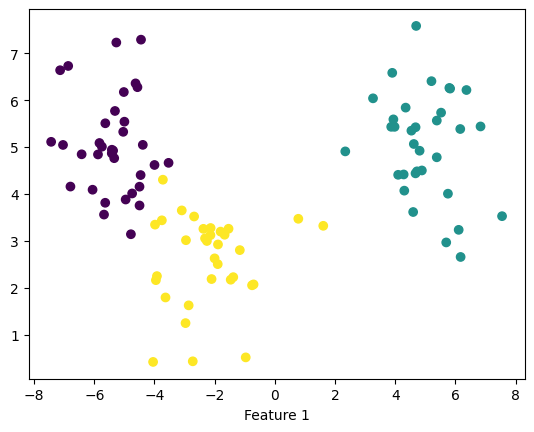

In [27]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

centroids = [(-5, 5), (5, 5), (-2.5, 2.5)]
cluster_std = [1 , 1, 1]
X, y = make_blobs(n_samples= 100, cluster_std = cluster_std, centers = centroids, n_features = 2, random_state = 2)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')

In [28]:
#Series of steps to follow:
#1. Decide on the number of clusters (k)
#2. Initialize k centroids randomly
#3. Assign each data point to the nearest centroid
#4. Update the centroids based on the mean of the points assigned to them
#5. Repeat steps 3 and 4 until convergence (centroids don't change significantly) or

In [29]:
import random
import numpy as np

In [53]:
class KMeans:
  def __init__(self, n_clusters = 4, max_iter= 1000):
    self.n_clusters = n_clusters
    self.max_iter = max_iter
    self.centroids = None

  def fit_predict(self, X):
    random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
    self.centroids = X[random_index]

    for i in range(self.max_iter):
      #Assign clusters
      cluster_group = self.assign_clusters(X)
      old_centroids = self.centroids

      #Move centroids
      self.centroids = self.move_centroids(X, cluster_group)
      #Check finish
      if (old_centroids == self.centroids).all():
        break
    return cluster_group

  def assign_clusters(self, X):
    cluster_group = []
    distances = []

    for row in X:
      for centroid in self.centroids:
        distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))
      min_distance = min(distances)
      index_pos = distances.index(min_distance)
      cluster_group.append(index_pos)
      distances.clear()

    return np.array(cluster_group)

  def move_centroids(self,X, cluster_group ):
    new_centroids = []
    cluster_type = np.unique(cluster_group)

    for type in cluster_type:
      new_centroids.append(X[cluster_group == type].mean(axis=0))
    return np.array(new_centroids)



In [34]:
km = KMeans(n_clusters=3, max_iter=200)
y_means = km.fit_predict(X) #We should get X (2D array)

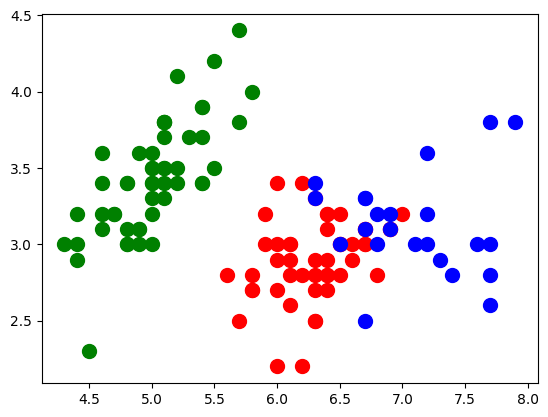

In [54]:
plt.scatter(X[y_means ==0, 0], X[y_means == 0, 1], s=100, c='red')
plt.scatter(X[y_means ==1, 0], X[y_means == 1, 1], s=100, c='blue')
plt.scatter(X[y_means ==2, 0], X[y_means == 2, 1], s=100, c='green')
plt.show()

In [39]:
#Algorithm on custom dataset
import seaborn as sns
df= sns.load_dataset('iris')

In [40]:
X = df.iloc[:, :].values

In [51]:

#Algorithm on custom dataset
df = sns.load_dataset('iris')

# Select only numerical features for clustering
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

km = KMeans(n_clusters=4, max_iter=1000)
y_means = km.fit_predict(X)

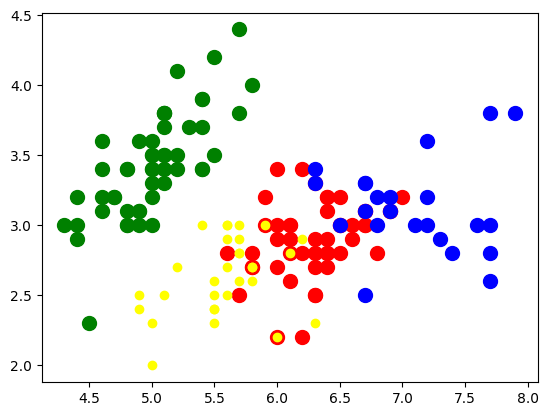

In [55]:
plt.scatter(X[y_means ==0, 0], X[y_means == 0, 1], s=100, c='red')
plt.scatter(X[y_means ==1, 0], X[y_means == 1, 1], s=100, c='blue')
plt.scatter(X[y_means ==2, 0], X[y_means == 2, 1], s=100, c='green')
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], color = 'yellow')
plt.show()

In [57]:
#To implement elbow method
#To calculate wcss
wcss = []
for i in range(1, 11):
  km = KMeans(n_clusters=i, max_iter=1000)
  km.fit_predict(X)
